# 使用预构建组件进行代理开发

LangGraph 提供了用于构建基于代理的应用程序的低级原语和高级预构建组件。本节重点介绍预构建的、即用型组件，旨在帮助您快速可靠地构建代理系统，而无需从头开始实现编排、内存或人工反馈处理。


## 什么是代理？
代理由三个组件组成：大型语言模型 (LLM) 、一组可以使用的工具以及提供指令的提示。

LLM 以循环方式运行。在每次迭代中，它会选择一个要调用的工具，提供输入，接收结果（观察结果），并使用该观察结果来指导下一步操作。循环持续进行，直到满足停止条件——通常是当代理收集到足够的信息来响应用户时。

<img src="https://langchain-ai.github.io/langgraph/agents/assets/agent.png" title="代理循环：LLM 选择工具并使用其输出来满足用户请求。">


## 主要特点¶
LangGraph 包含构建强大、可投入生产的代理系统所必需的几项功能：

- 内存集成：原生支持短期（基于会话）和长期（跨会话持久）内存，从而实现聊天机器人和助手的状态行为。
- 人机交互控制：执行可以无限期暂停，等待人工反馈——这与基于 WebSocket 的解决方案受限于实时交互不同。这使得在工作流程的任何阶段都能实现异步审批、更正或干预。
- 流支持：代理状态、模型令牌、工具输出或组合流的实时流。
- 部署工具：包含无需基础设施的部署工具。LangGraph平台支持测试、调试和部署。
    - Studio：用于检查和调试工作流程的可视化 IDE。
    - 支持多种生产部署选项。

## 高级构建块¶
LangGraph 附带一组预构建组件，用于实现常见的代理行为和工作流程。这些抽象构建于 LangGraph 框架之上，提供了更快的生产路径，同时保持了高级定制的灵活性。

使用 LangGraph 进行代理开发使您能够专注于应用程序的逻辑和行为，而不是构建和维护状态、内存和人工反馈的支持基础设施。


## 包生态系统¶
高级组件被组织成几个包，每个包都有特定的重点。


| 包㐮 | 描述 | 安装 |
| :--- | :--- | :--- |
| langgraph-prebuilt（部分 langgraph） | 用于创建代理的预构建组件 | pip install -U langgraph langchain |
| langgraph-supervisor | 构建主管代理的工具 | pip install -U langgraph-supervisor |
| langgraph-swarm | 构建群体多智能体系统的工具 | pip install -U langgraph-swarm |
| langchain-mcp-adapters | 用于工具和资源集成的MCP 服务器接口 | pip install -U langchain-mcp-adapters |
| langmem | 代理内存管理：短期和长期 | pip install -U langmem |
| agentevals | 评估代理绩效的实用程序 | pip install -U agentevals |

## 可视化代理图¶
使用以下工具可视化生成的图表 create_react_agent 并查看相应代码的概要。它允许您探索代理的基础架构，该基础架构由以下内容定义：

- [tools](https://langchain-ai.github.io/langgraph/how-tos/tool-calling/)：代理可以用来执行任务的工具（函数、API 或其他可调用对象）列表。
- [pre_model_hook](https://langchain-ai.github.io/langgraph/how-tos/create-react-agent-manage-message-history/)：在调用模型之前调用的函数。它可用于压缩消息或执行其他预处理任务。
- post_model_hook：模型调用后调用的函数。可用于实现护栏、人机交互流程或其他后处理任务。
- [response_format](https://langchain-ai.github.io/langgraph/agents/agents/#6-configure-structured-output)：用于约束最终输出类型的数据结构，例如pydantic BaseModel。

以下代码片段展示了如何使用创建上述代理（和底层图） `create_react_agent`：

In [3]:
from dotenv import load_dotenv
import os
load_dotenv()  # 加载环境变量

os.environ["OPENAI_API_KEY"] = "sk-zk22db24007fdf62470b55e0e84b574e58e6751014a8f1e3"  # 设置 OpenAI API 密钥
os.environ["OPENAI_API_BASE"] = "https://api.zhizengzeng.com/v1"  # 设置 OpenAI API 基础 URL

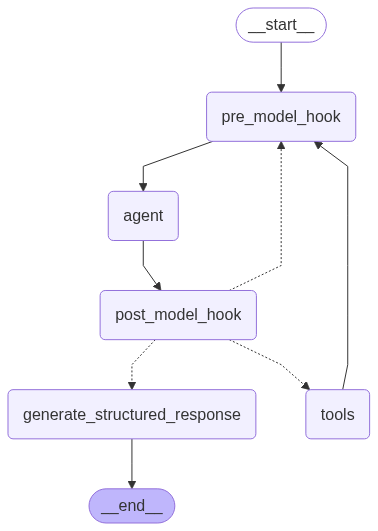

In [5]:
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
from IPython.display import display, Image

model = ChatOpenAI(model="o4-mini")

def tool() -> None:
    """Testing tool."""
    ...

def pre_model_hook() -> None:
    """Pre-model hook."""
    ...

def post_model_hook() -> None:
    """Post-model hook."""
    ...

class ResponseFormat(BaseModel):
    """Response format for the agent."""
    result: str

agent = create_react_agent(
    model,
    tools=[tool],
    pre_model_hook=pre_model_hook,
    post_model_hook=post_model_hook,
    response_format=ResponseFormat,
)

img_bytes = agent.get_graph().draw_mermaid_png()

display(Image(data=img_bytes))